In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

## 1. Data Preparation

In [2]:
# Load the CSV file with metadata
bee_data = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=';')

display(bee_data.head())

print(bee_data.shape)

display(bee_data.describe(include="all").T)

,file,health,split_group
0,040_070.png,unhealthy,train
1,040_328.png,unhealthy,train
2,010_441.png,healthy,train
3,015_770.png,healthy,train
4,038_149.png,unhealthy,train


(5172, 3)


,count,unique,top,freq
file,5172,5172,040_070.png,1
health,5172,2,healthy,3384
split_group,5172,3,train,4137


In [3]:
# Necessary features (X) and target (y)
x = bee_data[['file']].copy()
y = bee_data['health'].copy()

# Use the predefined split groups from processed metadata
split_col = bee_data['split_group'].str.lower()

x_train = x[split_col == 'train']
y_train = y[split_col == 'train']

x_val = x[split_col == 'val']
y_val = y[split_col == 'val']

x_test = x[split_col == 'test']
y_test = y[split_col == 'test']

# Shape / # rows, # columns for each split
print("Training")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("\nValidation")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print("\nTesting")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Number of unique classes
num_classes_train = len(np.unique(y_train))
num_classes_val = len(np.unique(y_val))
num_classes_test = len(np.unique(y_test))

print(f"Number of classes in training set: {num_classes_train}")
print(f"Number of classes in validation set: {num_classes_val}")
print(f"Number of classes in test set: {num_classes_test}\n")

print(bee_data[['file', 'split_group']].head(10), "\n")
print(bee_data['split_group'].value_counts())

Training
x_train shape: (4137, 1)
y_train shape: (4137,)

Validation
x_val shape: (517, 1)
y_val shape: (517,)

Testing
x_test shape: (518, 1)
y_test shape: (518,)

Number of classes in training set: 2
Number of classes in validation set: 2
Number of classes in test set: 2

           file split_group
0   040_070.png       train
1   040_328.png       train
2   010_441.png       train
3   015_770.png       train
4   038_149.png       train
5   032_361.png       train
6  019_1354.png       train
7  015_1260.png       train
8   032_547.png       train
9   040_363.png       train 

split_group
train    4137
test      518
val       517
Name: count, dtype: int64


We can see that we have:
healthy      3384
unhealthy    1788
bees...
This will definitely benefit from weight adjustments.

Class weights can be set to balanced inside Random Forest for simplification.

Train samples: 4137
Validation samples: 517
Test samples: 518
Image size: 128x128, batch size: 32


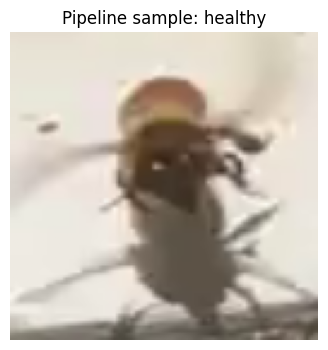

In [4]:
# Build an efficient input pipeline: load -> resize -> normalize -> batch -> prefetch
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Encode labels once; one-hot conversion happens inside the pipeline
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train.astype(str))
y_val_encoded = label_encoder.transform(y_val.astype(str))
y_test_encoded = label_encoder.transform(y_test.astype(str))
num_classes = len(label_encoder.classes_)

def make_paths(file_series):
    return file_series.astype(str).apply(
        lambda name: os.path.join("../data/bee_imgs", name)
    ).to_numpy()

train_paths = make_paths(x_train.iloc[:, 0])
val_paths = make_paths(x_val.iloc[:, 0])
test_paths = make_paths(x_test.iloc[:, 0])

def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0 # normalization
    image.set_shape((IMG_SIZE, IMG_SIZE, 3))
    label = tf.one_hot(label, depth=num_classes)
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, y_train_encoded, training=True)
val_ds = make_dataset(val_paths, y_val_encoded, training=False)
test_ds = make_dataset(test_paths, y_test_encoded, training=False)

print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}, batch size: {BATCH_SIZE}")

# Show one preprocessed sample image
for sample_images, sample_labels in train_ds.take(1):
    sample_image = sample_images[0].numpy()
    sample_label_idx = int(tf.argmax(sample_labels[0]).numpy())
    sample_label_name = label_encoder.inverse_transform([sample_label_idx])[0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Pipeline sample: {sample_label_name}")
plt.axis("off")
plt.show()

Feature Extraction and Feature Scaling


Exxtract fix-size image features (simple resized pixel intensities + color statistics), and then standardize them before training the Random Forest model.

Random Forest (classic ML) can't work directly with raw image pixel data (unlike CNN). Images are high-dimensional that would require millions of features. Feature extraction converts images into a smaller, more meaningful set of numbers that capture the important information.

In [5]:
import cv2
from skimage.feature import hog

# Feature extraction helper (shared logic, RF-ready now, reusable for SVM later)
def extract_features(img_bgr: np.ndarray) -> np.ndarray:
    """
    img_bgr: uint8 array (H, W, 3) in BGR format from cv2.imread.
    Returns: 1-D float32 feature vector.
    """
    img = cv2.resize(img_bgr, (128, 128))

    # 1) HOG on grayscale: texture + local shape
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feats = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )

    # 2) HSV histogram: color distribution (16 bins/channel => 48 dims)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_hist = np.concatenate([
        cv2.calcHist([hsv], [ch], None, [16], [0, 256]).flatten()
        for ch in range(3)
    ])

    # 3) RGB channel statistics: mean + std per channel (6 dims)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    rgb_stats = np.concatenate([
        [rgb[:, :, ch].mean(), rgb[:, :, ch].std()]
        for ch in range(3)
    ])

    return np.concatenate([hog_feats, hsv_hist, rgb_stats]).astype(np.float32)

def extract_dataset(image_paths):
    """Extract features for a list/array of image paths."""
    feats = []
    for path in image_paths:
        img = cv2.imread(str(path))
        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")
        feats.append(extract_features(img))
    return np.vstack(feats)

# Build feature matrices
x_train_features = extract_dataset(train_paths)
x_val_features = extract_dataset(val_paths)
x_test_features = extract_dataset(test_paths)

print(f"x_train_features shape: {x_train_features.shape}")
print(f"x_val_features shape: {x_val_features.shape}")
print(f"x_test_features shape: {x_test_features.shape}")

# Shared scaling logic (fit only on train)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_features)
x_val_scaled = scaler.transform(x_val_features)
x_test_scaled = scaler.transform(x_test_features)

x_train_features shape: (4137, 8154)
x_val_features shape: (517, 8154)
x_test_features shape: (518, 8154)


Images 128x128x3 + 6: 49 152 + 6
Meaning one feature for every pixel and rgb value + 3 mean and + 3 std per channel
Now we have a proper 2D matrix

In [6]:
# Model training: Random Forest (using engineered features from previous cell)
use_grid_search = False  # set True only if you want extra tuning complexity

if use_grid_search:
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
    }
    base_rf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )
    grid = GridSearchCV(
        estimator=base_rf,
        param_grid=param_grid,
        cv=3,
        scoring="f1_weighted",
        n_jobs=-1,
        verbose=1,
    )
    grid.fit(x_train_scaled, y_train)
    rf_model = grid.best_estimator_
    print("Best params:", grid.best_params_)
else:
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )
    rf_model.fit(x_train_scaled, y_train)
    print("Random Forest trained with baseline hyperparameters.")


# After 15 minutes of processing time for hyperparameter tuning:
# Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}

Random Forest trained with baseline hyperparameters.



Validation classification report:
              precision    recall  f1-score   support

     healthy       0.93      0.98      0.95       338
   unhealthy       0.96      0.85      0.91       179

    accuracy                           0.94       517
   macro avg       0.94      0.92      0.93       517
weighted avg       0.94      0.94      0.94       517

Test set classification report:
              precision    recall  f1-score   support

     healthy       0.92      0.97      0.94       339
   unhealthy       0.93      0.83      0.88       179

    accuracy                           0.92       518
   macro avg       0.92      0.90      0.91       518
weighted avg       0.92      0.92      0.92       518

Summary metrics (positive class = unhealthy):
Accuracy:  0.9208
Precision: 0.9313
Recall:    0.8324
F1-score:  0.8791
ROC-AUC:   0.9806


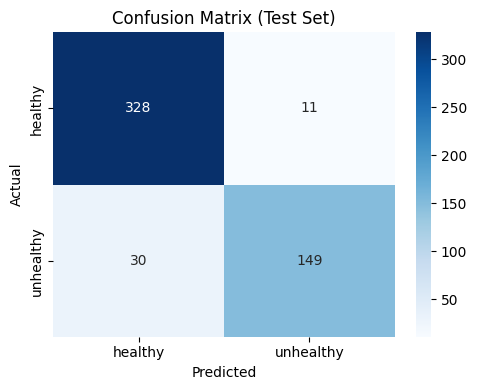

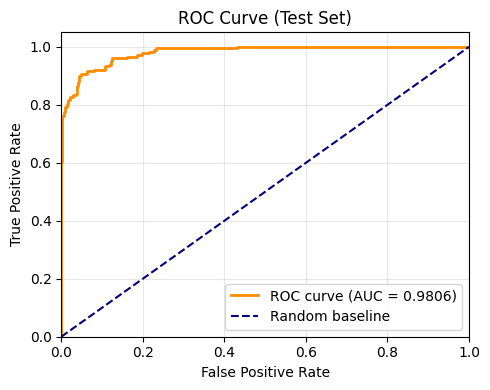

In [7]:

# Quick validation check before final test evaluation
y_val_pred = rf_model.predict(x_val_scaled)
print("\nValidation classification report:")
print(classification_report(y_val, y_val_pred))

# Final test set evaluation
y_pred = rf_model.predict(x_test_scaled)

# Core metrics on the held-out test set
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label="unhealthy")
rec = recall_score(y_test, y_pred, pos_label="unhealthy")
f1 = f1_score(y_test, y_pred, pos_label="unhealthy")

# ROC-AUC metrics use score values instead of hard labels
y_test_labels = y_test.astype(str).to_numpy()
y_test_binary = (y_test_labels == "unhealthy").astype(int)
unhealthy_idx = np.where(rf_model.classes_ == "unhealthy")[0][0]
y_score = rf_model.predict_proba(x_test_scaled)[:, unhealthy_idx]

fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

print("Test set classification report:")
print(classification_report(y_test, y_pred))

print("Summary metrics (positive class = unhealthy):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=["healthy", "unhealthy"])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"],
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve visualization
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", linewidth=1.5, linestyle="--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Precision: When it says 1 how often is it right
Recall/Sensitivity: What fraction of 1s does it get right (True Positive Rate – TPR)
F1score: How “good” are precision and recall
